In [1]:
# %% Libraries
import os
import scanpy as sc
#import scvi
import numpy as np
from pathlib import Path
import pandas as pd
import anndata as ad
import rapids_singlecell as rsc
#import novae

/mnt/data/project0062/.conda/envs/rsc_25.12/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# %% Setting Paths
MAIN_DIR_NAME = "proseg_data"
MAIN_DIR = next(p for p in Path.cwd().parents if (p / MAIN_DIR_NAME).exists()) / MAIN_DIR_NAME
os.chdir(MAIN_DIR)

# %% Setting Seed
SEED_VALUE = 42
# set NumPy RNG for consistency
np.random.seed(SEED_VALUE)

# %% object versions
CUR_OBJ_V = 'refined-manual-niches'
CUR_OBJ_PATH = MAIN_DIR / 'data' / 'comb' / 'h5ad' / f'comb-{CUR_OBJ_V}.h5ad'
NEW_OBJ_V = 'refined-manual-niches'
NEW_OBJ_PATH = MAIN_DIR / 'data' / 'comb' / 'h5ad' / f'comb-{NEW_OBJ_V}.h5ad'

# %% Load the unintegrated object
# use adata isntead of comb for the object only in this script
comb = sc.read_h5ad(CUR_OBJ_PATH)

In [3]:
comb.obs['condition'].value_counts()

condition
CF        836169
CTRL      205205
CF_ETI    145967
Name: count, dtype: int64

In [4]:
niches_map = {
    '0': 'interstitium',
    '1': 'plasma_rich',
    '2': 'airway_epithelium',
    '3': 'neutrophil_rich',
    '4': 'BALT',
    '5': 'alveolar',
}

# level
niche_level_name = 'niches_k_6'

# %% Map the niches to the new labels
comb.obs['niche_name'] = comb.obs[niche_level_name].map(niches_map)

/mnt/data/project0062/.conda/envs/rsc_25.12/lib/python3.13/site-packages/scanpy/plotting/_utils.py:507: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[f"{value_to_plot}_colors"] = colors_list


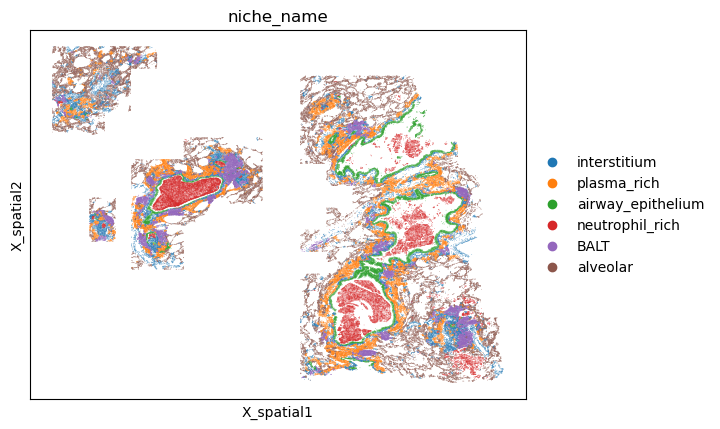

In [5]:
# plot 

mask = comb.obs['sample_name'] == 'PWCF01_1'

sc.pl.embedding(
    comb[mask],
    basis='X_spatial',
    color='niche_name'
)

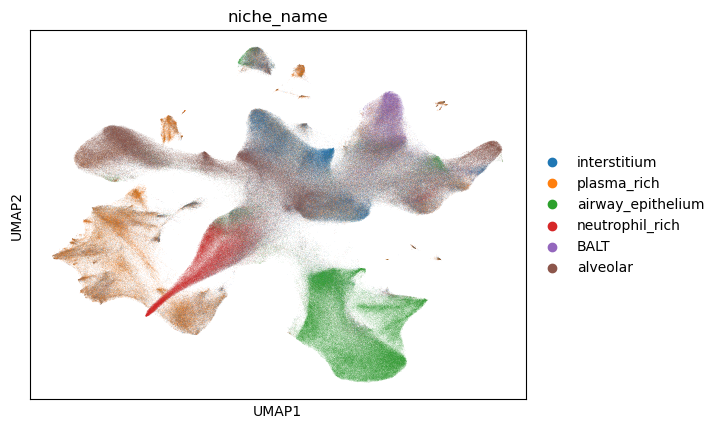

In [10]:
# doing this only to register the colours in comb.uns
sc.pl.umap(
    comb,
    color='niche_name'
)

In [11]:
ANN_VAR = "niche_name"

# %% colors

categories = comb.obs[ANN_VAR].cat.categories
colors = comb.uns[f"{ANN_VAR}_colors"]

print(colors)

['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']


In [12]:
comb.uns

{'_scvi_manager_uuid': '61739dc0-85ae-4eb0-9da6-33961203158b',
 '_scvi_uuid': '5f63e281-6c0e-4fa9-9d2b-9550c7e7d5f2',
 'ann_lvl_1_colors': array(['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd'],
       dtype=object),
 'ann_lvl_2_colors': array(['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b',
        '#e377c2'], dtype=object),
 'ann_lvl_3_colors': array(['#023fa5', '#7d87b9', '#bec1d4', '#d6bcc0', '#bb7784', '#8e063b',
        '#4a6fe3', '#8595e1', '#b5bbe3', '#e6afb9', '#e07b91', '#d33f6a',
        '#11c638', '#8dd593', '#c6dec7', '#ead3c6', '#f0b98d', '#ef9708',
        '#0fcfc0', '#9cded6', '#d5eae7'], dtype=object),
 'ann_lvl_3_refined_colors': array(['#ffff00', '#1ce6ff', '#ff34ff', '#ff4a46', '#008941', '#006fa6',
        '#a30059', '#ffdbe5', '#7a4900', '#0000a6', '#63ffac', '#b79762',
        '#004d43', '#8fb0ff', '#997d87', '#5a0007', '#809693', '#6a3a4c',
        '#1b4400', '#4fc601', '#3b5dff', '#4a3b53', '#ff2f80', '#61615a',
        '#ba0900', '#6b7

In [13]:
# save the annotated object 
comb.write_h5ad(NEW_OBJ_PATH)